# **Dataset context**

The Garbage Classification dataset was created to support the development of machine learning models for automated waste sorting and recycling systems. It consists of labeled images of various types of garbage, such as cardboard, glass, metal, paper, plastic and general trash. The goal is to train models to recognize and classify these waste types based on visual characteristics.

This dataset is particularly useful for computer vision applications in environmental sustainability, where automatic identification of recyclable materials can aid in improving waste management efficiency, reducing human error and supporting smart bin technologies. Its real-world variability—such as different lighting, angles, and backgrounds—makes it suitable for building robust image classification systems.

# **Dataset content**

* **Total Classes**: 6 categories of garbage:

 - 1. cardboard

 - 2. glass

 - 3. metal

 - 4. paper

 - 5. plastic

 - 6. trash

* **File Format**: Images are stored as .jpg files. Typical image dimensions vary (e.g., ~384x512 pixels), but can be resized for modeling.

* **Labeling**: Each folder name serves as the class label for the images it contains.

* **Number of Images**: ~2,500–2,600 total images (approx. 400–500 per class).

* **Image Variety**: Photos include various object shapes, sizes, and backgrounds to mimic real-world conditions. Some images show used/dirty items, others are clean, making it suitable for generalization.

*(source: https://www.kaggle.com/datasets/asdasdasasdas/garbage-classification/data)*

# **Imports**

In [48]:
# Standard Library Imports
import glob
import os
import zipfile
from typing import Dict, Union, List

# Data Manipulation & Visualization
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Utility & Interface
from IPython.display import display
import ipywidgets as widgets

# Image Processing
from PIL import Image
from skimage import io, transform

# Machine Learning & Model Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Deep Learning – Keras
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D, BatchNormalization, Activation
from tensorflow.keras.metrics import Precision, Recall, AUC, TopKCategoricalAccuracy
from tensorflow.keras import regularizers

# Deep Learning – TensorFlow (Keras backend)
import tensorflow as tf
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import Model, Input

# Deep Learning – PyTorch
import torch

# **Functions**

In [3]:
def handle_upload(change: dict) -> None:
    """
    Handles the upload event for Kaggle JSON credential file.
    """
    if uploader.value:
        for fname, file in uploader.value.items():
            # Save the file temporarily
            with open("kaggle.json", "wb") as f:
                f.write(file["content"])
                print("kaggle.json saved locally.")

        # Create the .kaggle directory if it doesn't exist
        kaggle_dir = os.path.expanduser("~/.kaggle")
        os.makedirs(kaggle_dir, exist_ok=True)
        # Move the file to ~/.kaggle
        os.replace("kaggle.json", os.path.join(kaggle_dir, "kaggle.json"))
        print("kaggle.json moved to ~/.kaggle")

In [4]:
def load_and_inspect_dataset(set_path: str, label_map: Dict[int, str])-> pd.DataFrame:
    """
    Loads training data from a CSV file, inspects its structure, maps numeric labels to class names,
    and prints summary information.
    """
    # Read the train data
    df = pd.read_csv(set_path, header=None, names=['picture', 'label'], delimiter=" ")

    # Display top 5 rows
    print("First 5 rows of the dataset:")
    print(df.head())

    # Check for missing values
    print("\n\nMissing values in each column:")
    print(df.isnull().sum())

    # Map label integers to class names
    df['label_name'] = df['label'].map(label_map)

    # Display dataset size
    print(f"\n\nTotal number of training examples: {len(df)}")

    # Show class distribution
    print("\n\nLabel distribution:")
    print(df['label'].value_counts())

    # Show info about DataFrame
    print("\n\nDataFrame info:")
    df.info()

    return df

In [5]:
def plot_label_distribution(df: pd.DataFrame) -> None:
    """
    Generates and displays a count plot for label distribution in the given DataFrame.
    """
    sns.set(style="whitegrid")
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x='label_name', order=df['label_name'].value_counts().index)
    plt.xlabel('Label')
    plt.ylabel('Count')
    plt.title('Label Distribution in train_df')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [6]:
def display_sample_images(df: pd.DataFrame, data_dir: Union[str, os.PathLike]) -> None:
    """
    Displays one sample image per class from the training dataset with class labels.
    """
    classes = df['label_name'].unique()
    for label in classes:
        # Get the first sample image for the label
        sample = df[df['label_name'] == label].iloc[0]
        img_path = os.path.join(data_dir, sample['label_name'], str(sample['picture']))

        try:
            img = Image.open(img_path)
            plt.figure()
            plt.imshow(img)
            plt.title(f"Label: {label}")
            plt.axis('off')
            plt.show()
        except FileNotFoundError:
            print(f"Image file not found: {img_path}")

In [7]:
def evaluate_model(trained_model: Sequential) -> None:
    """
    Visualizes the training and validation accuracy and loss over epochs from a trained Keras model.
    """
    accuracy = trained_model.history.history['accuracy']
    val_accuracy = trained_model.history.history['val_accuracy']
    loss = trained_model.history.history['loss']
    val_loss = trained_model.history.history['val_loss']
    epochs = range(len(accuracy))

    plt.plot(epochs, accuracy, 'bo', label='Training accuracy')
    plt.plot(epochs, val_accuracy, 'b', label='Validation accuracy')
    plt.title('Training and validation accuracy')
    plt.legend()

    plt.figure()
    plt.plot(epochs, loss, 'bo', label='Training loss')
    plt.plot(epochs, val_loss, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()

    plt.show()

In [8]:
def plot_confusion_matrix(model: Sequential, test_iterator) -> None:
    """
    Generates and displays a visually enhanced confusion matrix for a given model's predictions.
    """
    y_true = test_iterator.classes
    y_pred_probs = model.predict(test_iterator, verbose=1)
    y_pred = np.argmax(y_pred_probs, axis=1)
    labels = [label for label, index in sorted(test_iterator.class_indices.items(), key=lambda x: x[1])]

    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(12, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap='Blues', xticks_rotation=45, colorbar=False)

    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(False)

    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

In [9]:
def generate_confusion_matrix_and_classification_report(model: Sequential, test_iterator) -> None:
    """
    Computes and returns the confusion matrix for a given model and test data iterator.
    """
    # Ensure consistent results by resetting the iterator
    test_iterator.reset()

    # Ground truth labels
    y_true = test_iterator.classes

    # Model predictions
    y_pred_probs = model.predict(test_iterator, verbose=1)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Display label mapping
    sorted_labels = [label for label, index in sorted(test_iterator.class_indices.items(), key=lambda x: x[1])]
    print("Label order:", sorted_labels)

    # Print confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:\n", cm)

In [10]:
def predict_image(model, img_path, class_labels) -> str:
    """
    Predicts the class of an input image using a trained MobileNetV2 model.
    """

    # Load and preprocess the image
    img = image.load_img(img_path, target_size=(128, 128))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    # Predict
    predictions = model.predict(img_array)
    predicted_index = np.argmax(predictions, axis=1)[0]
    predicted_label = class_labels[predicted_index]

    # Show image and prediction
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Predicted: {predicted_label}")
    plt.show()

    return predicted_label

In [11]:
def count_params_manual(weights: List[tf.Variable]) -> int:
    """
    Manually count the number of parameters in a list of TensorFlow weights.
    """
    return int(np.sum([np.prod(w.shape) for w in weights]))

In [58]:
def save_model_performance(name: str,
                           test_acc: List[float],
                           test_loss: List[float],
                           val_acc: List[float],
                           val_loss: List[float],
                           train_params: List[int],
                           non_train_params: List[int],
                           model: Model,
                           test_eval: List[float]) -> None:
    """
    Appends performance metrics and parameter counts of a model to tracking lists.
    """
    model_name.append(name)
    test_acc.append(test_eval[1])
    test_loss.append(test_eval[0])
    val_acc.append(val_eval[1])
    val_loss.append(val_eval[0])
    train_params.append(count_params_manual(model.trainable_weights))
    non_train_params.append(count_params_manual(model.non_trainable_weights))

# **Data preparation and downloading**

In [24]:
# Upload kaggle.json
uploader = widgets.FileUpload(accept='.json', multiple=False)
display(uploader)

FileUpload(value={}, accept='.json', description='Upload')

kaggle.json saved locally.
kaggle.json moved to ~/.kaggle


In [28]:
# Attach the handler to the uploader
uploader.observe(handle_upload, names='value')

In [29]:
# Download dataset
!kaggle datasets download -d asdasdasasdas/garbage-classification

Dataset URL: https://www.kaggle.com/datasets/asdasdasasdas/garbage-classification
License(s): copyright-authors
  0% 0.00/82.0M [00:00<?, ?B/s]
100% 82.0M/82.0M [00:00<00:00, 1.19GB/s]


In [30]:
# Unzip the data
with zipfile.ZipFile("garbage-classification.zip", 'r') as zip_ref:
    zip_ref.extractall("garbage_dataset")

In [31]:
# The data consists of 5 text files
for root, dirs, files in os.walk("garbage_dataset"):
    print(f"Directory: {root}")
    print(f"Files: {files[:5]}")
    break

Directory: garbage_dataset
Files: ['one-indexed-files-notrash_val.txt', 'one-indexed-files-notrash_test.txt', 'zero-indexed-files.txt', 'one-indexed-files-notrash_train.txt', 'one-indexed-files.txt']


# EDA

In [32]:
# There are 6 labels of garbage: cardboard, glass, metal, paper, plastic and trash
data_dir  = './garbage_dataset/Garbage classification/Garbage classification'

classes = os.listdir(data_dir)
print(classes)

['glass', 'trash', 'plastic', 'paper', 'cardboard', 'metal']


In [33]:
# Define train, test and val sets paths
train_dir = './garbage_dataset/one-indexed-files-notrash_train.txt'
test_dir = './garbage_dataset/one-indexed-files-notrash_test.txt'
val_dir = './garbage_dataset/one-indexed-files-notrash_val.txt'

In [34]:
# Map the labels of data to put them on the plots
label_map = {1: 'glass', 2: 'paper', 3: 'cardboard', 4: 'plastic', 5: 'metal', 6: 'trash'}

## **Train set**

In [35]:
# There are no missing values
# Total number of examples for train set is 1768
train_df = load_and_inspect_dataset(train_dir, label_map)

First 5 rows of the dataset:
            picture  label
0  cardboard202.jpg      3
1      paper472.jpg      2
2      paper522.jpg      2
3      glass189.jpg      1
4      glass325.jpg      1


Missing values in each column:
picture    0
label      0
dtype: int64


Total number of training examples: 1768


Label distribution:
label
2    403
1    354
4    347
3    287
5    286
6     91
Name: count, dtype: int64


DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1768 entries, 0 to 1767
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   picture     1768 non-null   object
 1   label       1768 non-null   int64 
 2   label_name  1768 non-null   object
dtypes: int64(1), object(2)
memory usage: 41.6+ KB


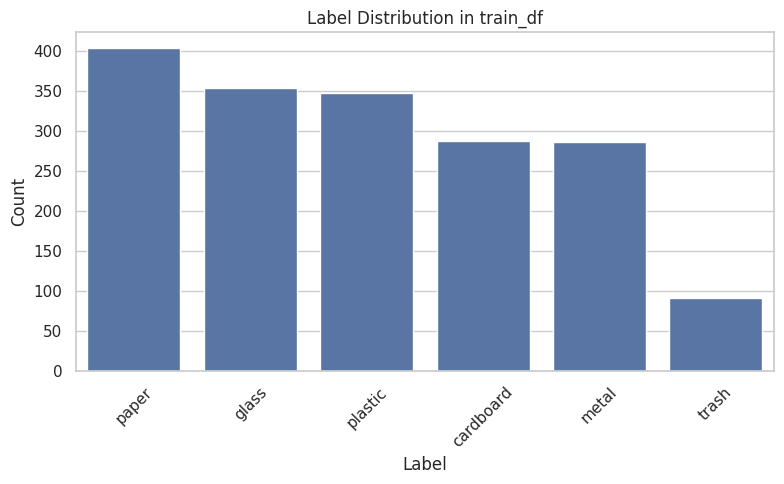

In [36]:
# There are the most glass examples (403) and the least trash examples (91)
plot_label_distribution(train_df)

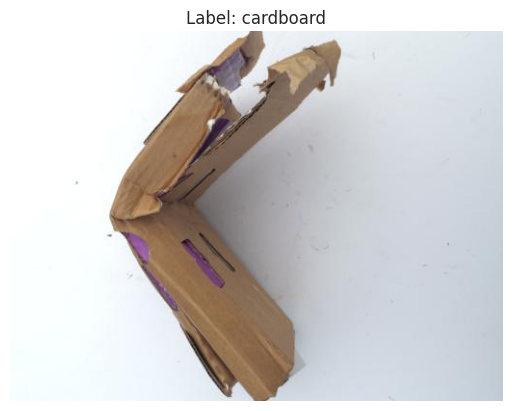

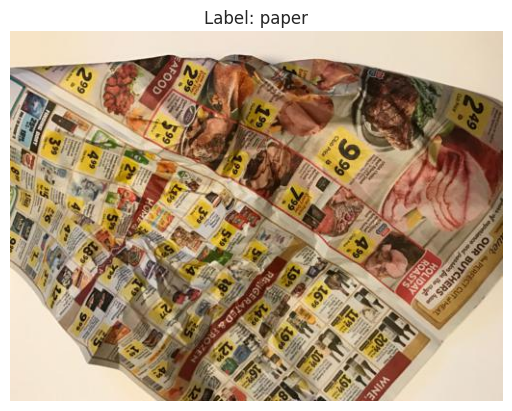

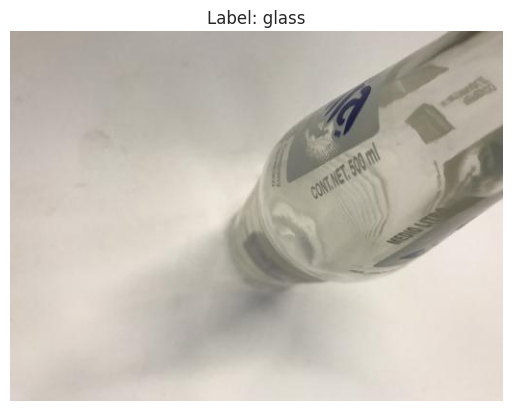

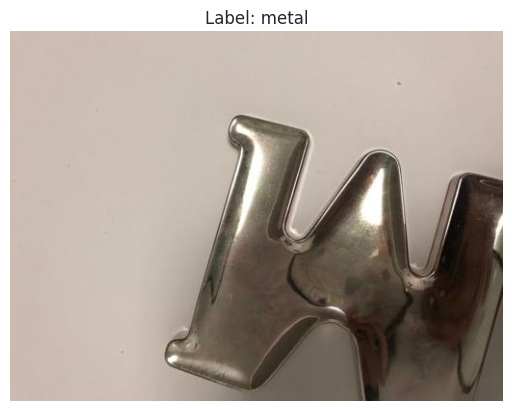

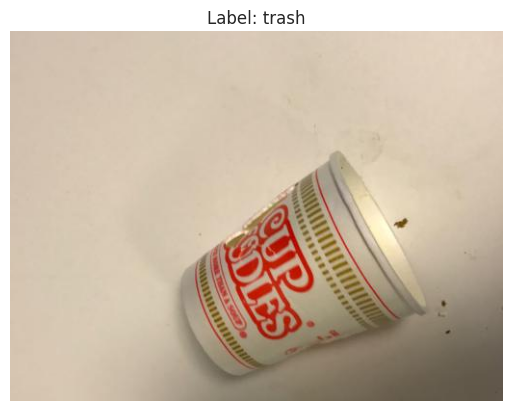

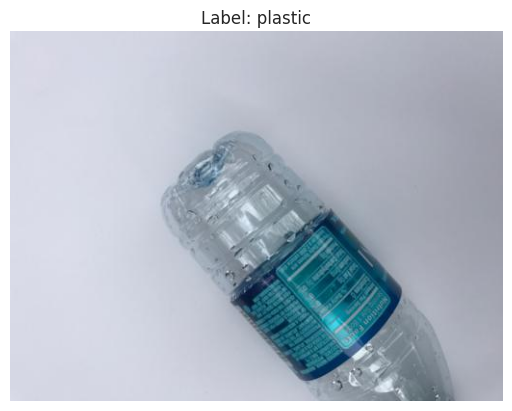

In [37]:
# Display sample images per class for train set
display_sample_images(train_df, data_dir)

## **Test set**

In [38]:
# There are no missing values
# Total number of examples for train set is 431
test_df = load_and_inspect_dataset(test_dir, label_map)

First 5 rows of the dataset:
           picture  label
0      paper70.jpg      2
1     paper380.jpg      2
2  cardboard31.jpg      3
3      glass12.jpg      1
4     paper169.jpg      2


Missing values in each column:
picture    0
label      0
dtype: int64


Total number of training examples: 431


Label distribution:
label
2    108
1     82
4     74
3     70
5     68
6     29
Name: count, dtype: int64


DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 431 entries, 0 to 430
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   picture     431 non-null    object
 1   label       431 non-null    int64 
 2   label_name  431 non-null    object
dtypes: int64(1), object(2)
memory usage: 10.2+ KB


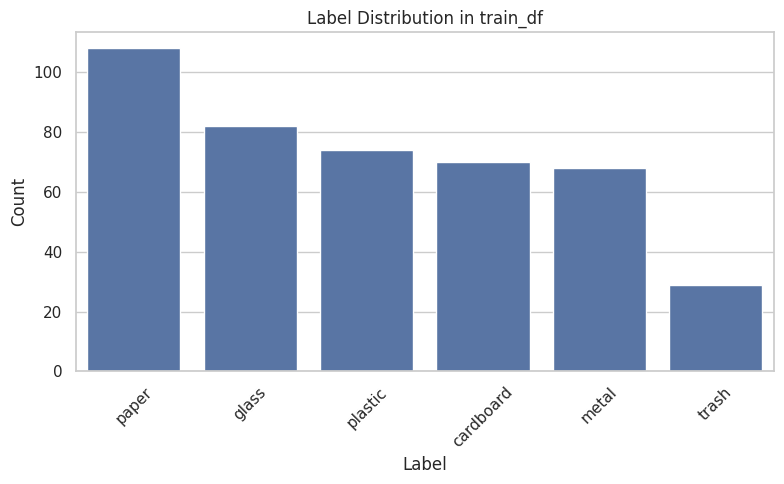

In [39]:
# There are the most glass examples (108) and the least trash examples (29)
plot_label_distribution(test_df)

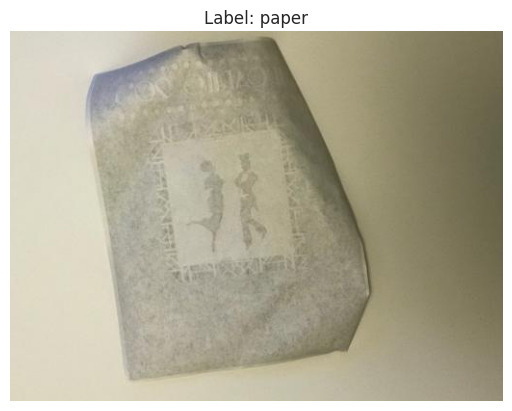

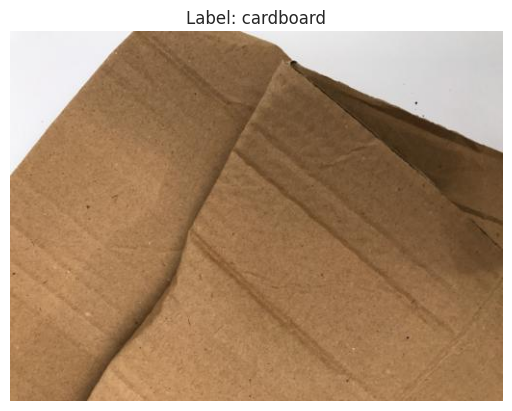

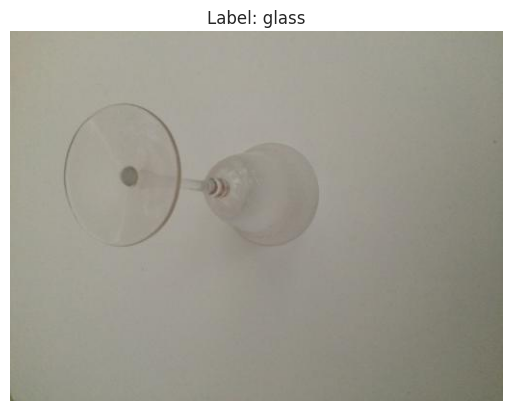

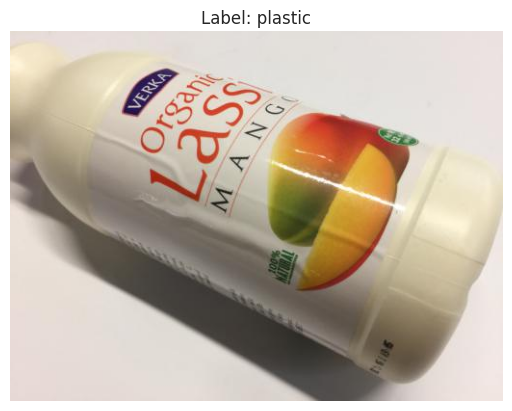

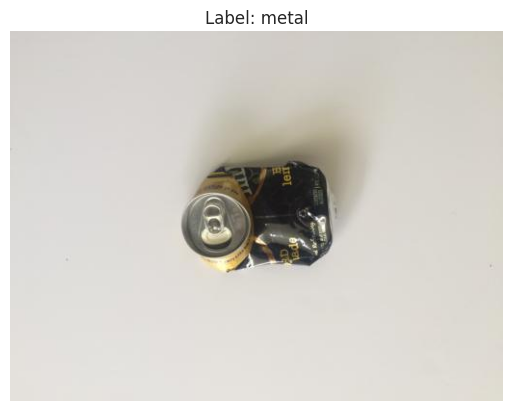

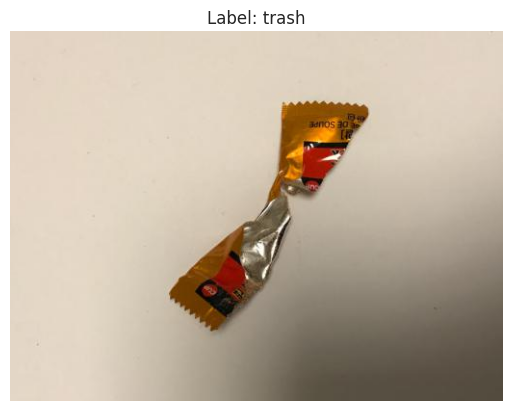

In [40]:
# Display sample images per class for test set
display_sample_images(test_df, data_dir)

## **Validation set**

In [41]:
# There are no missing values
# Total number of examples for train set is 328
val_df = load_and_inspect_dataset(val_dir, label_map)

First 5 rows of the dataset:
            picture  label
0  cardboard114.jpg      3
1    plastic204.jpg      4
2      glass123.jpg      1
3      glass152.jpg      1
4      glass398.jpg      1


Missing values in each column:
picture    0
label      0
dtype: int64


Total number of training examples: 328


Label distribution:
label
2    83
1    65
4    61
5    56
3    46
6    17
Name: count, dtype: int64


DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 328 entries, 0 to 327
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   picture     328 non-null    object
 1   label       328 non-null    int64 
 2   label_name  328 non-null    object
dtypes: int64(1), object(2)
memory usage: 7.8+ KB


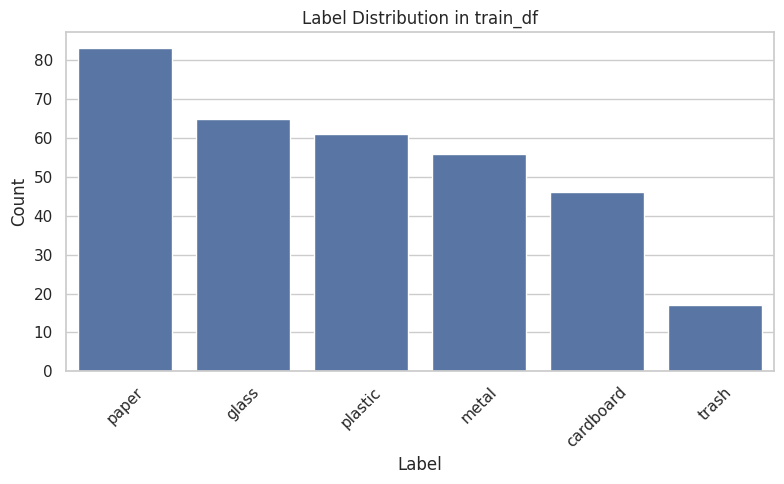

In [42]:
# There are the most glass examples (83) and the least trash examples (17)
plot_label_distribution(val_df)

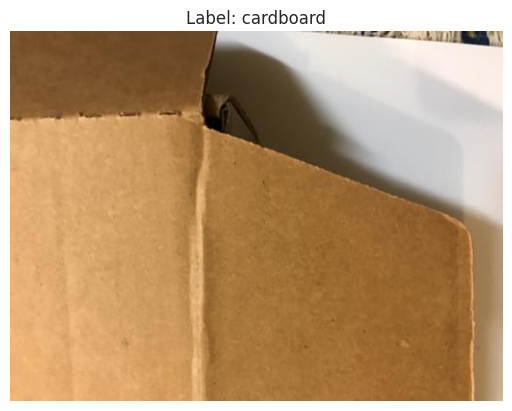

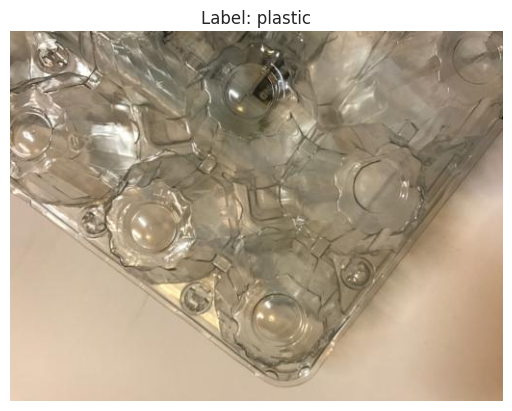

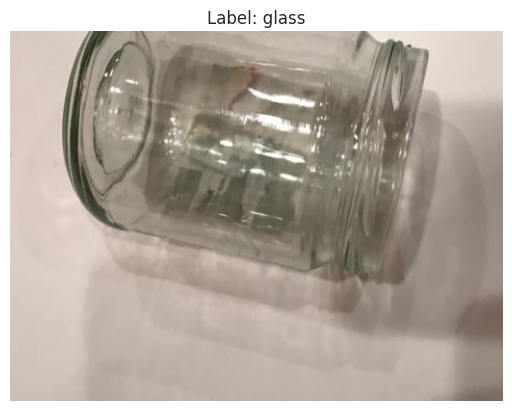

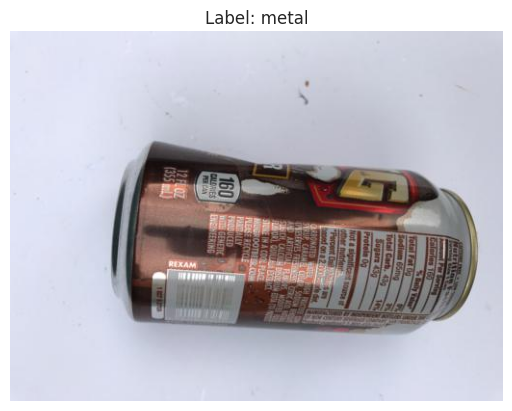

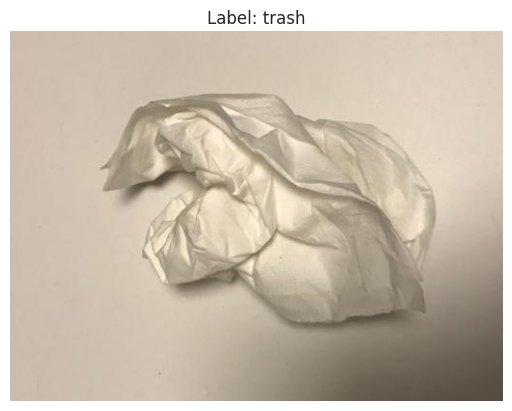

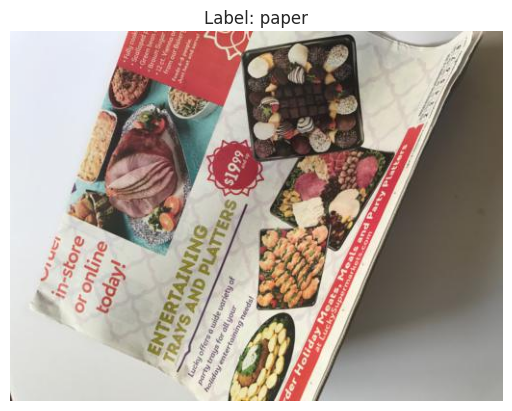

In [43]:
# Display sample images per class for test set
display_sample_images(val_df, data_dir)

# Generators and iterators for each set

In [44]:
# Define relative paths for all sets
train_df['rel_path'] = train_df['label_name']+'/'+train_df['picture']
test_df['rel_path'] = test_df['label_name']+'/'+test_df['picture']
val_df['rel_path'] = val_df['label_name']+'/'+val_df['picture']

In [45]:
# Generators
train_generator = ImageDataGenerator(
    rescale = 1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
val_generator = ImageDataGenerator(rescale = 1./255)
test_generator = ImageDataGenerator(rescale = 1./255)

In [46]:
# Iterators
train_iterator = train_generator.flow_from_dataframe(train_df,
                                                     directory = data_dir,
                                                    x_col='rel_path',
                                                    y_col='label_name',
                                                    target_size=(128, 128),
                                                    batch_size=32,
                                                    class_mode='categorical',
                                                    shuffle=True)

val_iterator = val_generator.flow_from_dataframe(val_df,
                                                 directory =  data_dir,
                                                    x_col='rel_path',
                                                    y_col='label_name',
                                                    target_size=(128, 128),
                                                    batch_size=32,
                                                    class_mode='categorical',
                                                    shuffle=True)

test_iterator = test_generator.flow_from_dataframe(test_df,
                                                    directory = data_dir,
                                                    x_col='rel_path',
                                                    y_col='label_name',
                                                    target_size=(128, 128),
                                                    batch_size=32,
                                                    class_mode='categorical',
                                                    shuffle=True)

Found 1768 validated image filenames belonging to 6 classes.
Found 328 validated image filenames belonging to 6 classes.
Found 431 validated image filenames belonging to 6 classes.


# Models

In [59]:
# Gather results for each model
model_name = []
test_acc = []
test_loss = []
val_acc = []
val_loss = []
train_params = []
non_train_params = []

## Model 1

In [49]:
# Architecture (CNN with MaxPooling)
model_I = Sequential()

model_I.add(Conv2D(32, (5,5), activation='relu', input_shape=(128,128,3)))
model_I.add(MaxPooling2D(4, 4))

model_I.add(Conv2D(64, (3,3), activation='relu'))
model_I.add(MaxPooling2D(4, 4))

model_I.add(Conv2D(64, (3,3), activation='relu'))
model_I.add(MaxPooling2D(2, 2))

model_I.add(Flatten())
model_I.add(Dense(64, activation='relu'))
model_I.add(Dense(6, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [50]:
# Model compilation
model_I.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy',
                       Precision(name='precision'),
                       Recall(name='recall'),
                       TopKCategoricalAccuracy(k=2, name='top2_acc')]
                )

In [51]:
# Loss and accuracy for test set before training
test_eval = model_I.evaluate(test_iterator, verbose=0)
print('Test loss:', test_eval[0])
print('Test accuracy:', test_eval[1])

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Test loss: 1.7751500606536865
Test accuracy: 0.17169374227523804


In [52]:
# Loss and accuracy for validation set before training
val_eval = model_I.evaluate(val_iterator, verbose=0)
print('Initial validation loss:', val_eval[0])
print('Initial validation accuracy:', val_eval[1])

Initial validation loss: 1.7590521574020386
Initial validation accuracy: 0.18902438879013062


In [53]:
history = model_I.fit(train_iterator, epochs=10, validation_data=val_iterator, batch_size=128)

Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 47s 784ms/step - accuracy: 0.2480 - loss: 1.7123 - precision: 0.0000e+00 - recall: 0.0000e+00 - top2_acc: 0.4372 - val_accuracy: 0.2927 - val_loss: 1.6535 - val_precision: 0.6667 - val_recall: 0.0183 - val_top2_acc: 0.5122
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 41s 733ms/step - accuracy: 0.3483 - loss: 1.6191 - precision: 0.4005 - recall: 0.0107 - top2_acc: 0.5551 - val_accuracy: 0.4055 - val_loss: 1.5198 - val_precision: 0.6667 - val_recall: 0.0305 - val_top2_acc: 0.5762
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 41s 727ms/step - accuracy: 0.3895 - loss: 1.5275 - precision: 0.6527 - recall: 0.0592 - top2_acc: 0.5851 - val_accuracy: 0.3750 - val_loss: 1.5455 - val_precision: 0.6744 - val_recall: 0.0884 - val_top2_acc: 0.5732
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 41s 731ms/step - accuracy: 0.4064 - loss: 1.4747 - precision: 0.6788 - recall: 0.1229 - top2_acc: 0.6189 - val_accuracy: 0.4573 - val_loss: 1.4315 - val_precision: 0.7719 - val_recall: 0.1341 - v

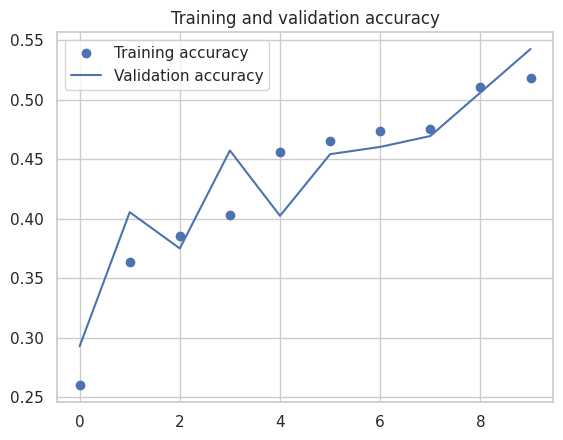

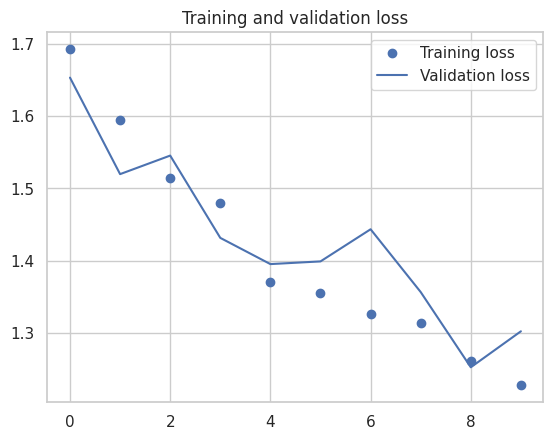

In [54]:
evaluate_model(model_I)

14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 184ms/step


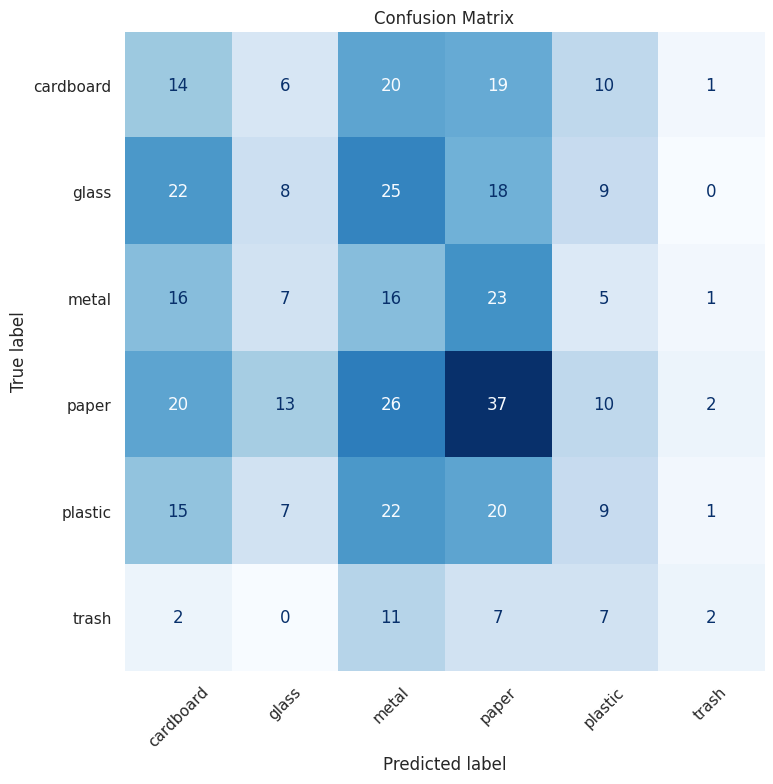

In [55]:
plot_confusion_matrix(model_I, test_iterator)

In [56]:
generate_confusion_matrix_and_classification_report(model_I, test_iterator)

14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 287ms/step
Label order: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Confusion Matrix:
 [[18  8 18 21  5  0]
 [10  7 23 30  9  3]
 [14  7 20 17  9  1]
 [29  5 28 31 13  2]
 [12 11 21 19 11  0]
 [ 6  3 10  6  3  1]]


In [60]:
# Save model performance
save_model_performance(name="Simple neural network",
                       test_acc=test_acc,
                       test_loss=test_loss,
                       val_acc=val_acc,
                       val_loss=val_loss,
                       train_params=train_params,
                       non_train_params=non_train_params,
                       model=model_I,
                       test_eval=test_eval)

* Training Accuracy improved from 22.96% to 45.36%.
* Validation Accuracy improved from 25.3% to 45.73%.
* Both training and validation loss consistently decreased, indicating that the model is learning well without overfitting.
* Most correct predictions appear on the diagonal (e.g., 52 for paper, 45 for cardboard).
* Paper is often misclassified as metal (15 times) and plastic (35 times).
* Plastic also gets confused with glass (13 times).
* Metal is frequently misclassified as paper (13 times).
* There are no examples of trach class.

## Model 2 (dropout)

In [61]:
model_II = Sequential()

model_II.add(Conv2D(32, (5,5), activation='relu', input_shape=(128,128,3)))
model_II.add(MaxPooling2D(4, 4))
model_II.add(Dropout(0.2))

model_II.add(Conv2D(64, (3,3), activation='relu'))
model_II.add(MaxPooling2D(4, 4))
model_II.add(Dropout(0.2))

model_II.add(Conv2D(64, (3,3), activation='relu'))
model_II.add(MaxPooling2D(2, 2))
model_II.add(Dropout(0.2))

model_II.add(Flatten())
model_II.add(Dense(64, activation='relu'))
model_II.add(Dense(6, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [62]:
model_II.compile(optimizer='adam',
                 loss='categorical_crossentropy',
                 metrics=['accuracy',
                       Precision(name='precision'),
                       Recall(name='recall'),
                       TopKCategoricalAccuracy(k=2, name='top2_acc')]
                )

In [63]:
# Loss and accuracy for test set before training
test_eval = model_I.evaluate(test_iterator, verbose=0)
print('Test loss:', test_eval[0])
print('Test accuracy:', test_eval[1])

Test loss: 1.199399709701538
Test accuracy: 0.5568445324897766


In [64]:
# Loss and accuracy for validation set before training
val_eval = model_I.evaluate(val_iterator, verbose=0)
print('Initial validation loss:', val_eval[0])
print('Initial validation accuracy:', val_eval[1])

Initial validation loss: 1.3020178079605103
Initial validation accuracy: 0.542682945728302


In [65]:
history_II = model_II.fit(train_iterator, epochs=10, validation_data=val_iterator, batch_size=128)

Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 44s 745ms/step - accuracy: 0.2060 - loss: 1.7446 - precision: 0.0000e+00 - recall: 0.0000e+00 - top2_acc: 0.4045 - val_accuracy: 0.2530 - val_loss: 1.7021 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_top2_acc: 0.4573
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 41s 729ms/step - accuracy: 0.2805 - loss: 1.6728 - precision: 0.2376 - recall: 0.0014 - top2_acc: 0.4686 - val_accuracy: 0.2805 - val_loss: 1.6943 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_top2_acc: 0.5152
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 41s 728ms/step - accuracy: 0.3261 - loss: 1.6171 - precision: 0.7434 - recall: 0.0266 - top2_acc: 0.5312 - val_accuracy: 0.3445 - val_loss: 1.5967 - val_precision: 0.3750 - val_recall: 0.0091 - val_top2_acc: 0.5884
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 41s 732ms/step - accuracy: 0.3382 - loss: 1.5797 - precision: 0.6229 - recall: 0.0473 - top2_acc: 0.5643 - val_accuracy: 0.3689 - val_loss: 1.5228 - val_precision: 0.6842 - val_re

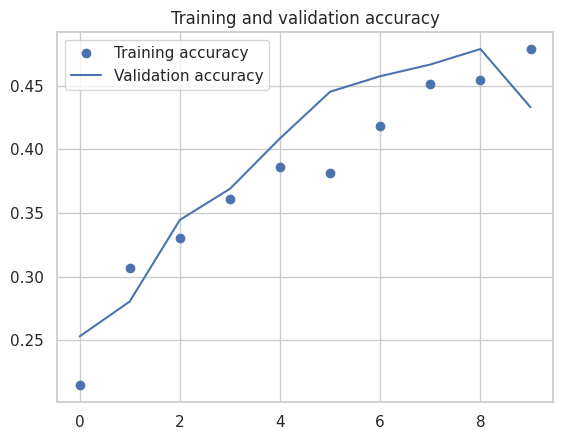

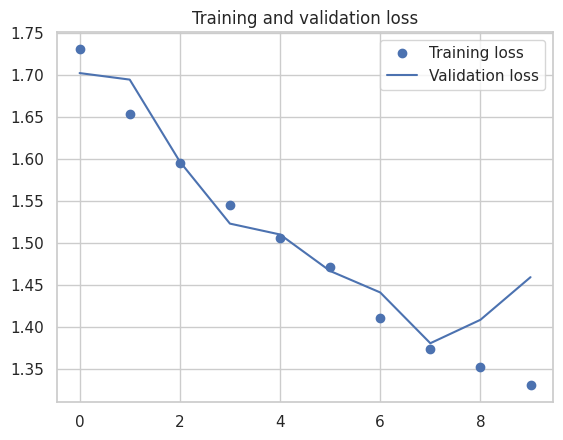

In [66]:
evaluate_model(model_II)

14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 185ms/step


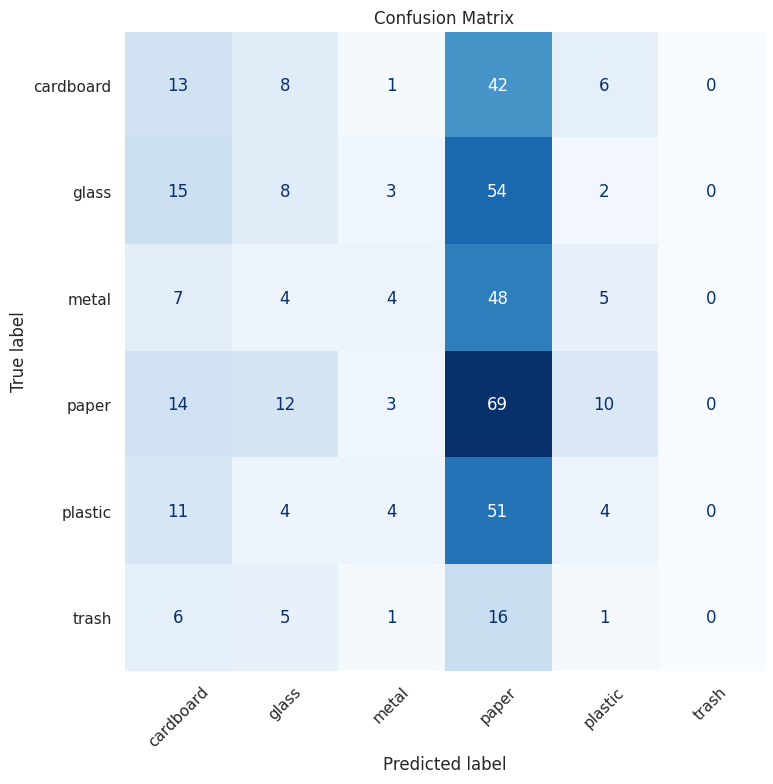

In [67]:
plot_confusion_matrix(model_II, test_iterator)

In [68]:
generate_confusion_matrix_and_classification_report(model_II, test_iterator)

14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 180ms/step
Label order: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Confusion Matrix:
 [[10  5  4 50  1  0]
 [11  3  3 62  3  0]
 [11  7  0 47  3  0]
 [14 10  5 69 10  0]
 [14 13  3 36  8  0]
 [ 6  3  1 16  3  0]]


In [69]:
# Save model performance
save_model_performance(name="Neural network with dropout",
                       test_acc=test_acc,
                       test_loss=test_loss,
                       val_acc=val_acc,
                       val_loss=val_loss,
                       train_params=train_params,
                       non_train_params=non_train_params,
                       model=model_II,
                       test_eval=test_eval)

* Training accuracy increased from 15.76% to 38.46%.

* Validation loss dropped from 1.7555 to 1.5205 (a reduction of 13.4%).

* Training and validation curves show steady learning with no major signs of overfitting.
* Glass class performance is weak: only 8/82 correctly predicted — accuracy ~9.75%.

* Trash class not detected at all: suggests feature overlap or lack of representation.

* Paper class is best-performing: 52/108 correct — accuracy ~48.15%.

* High confusion between paper, glass, plastic, and metal, which may share visual traits.

## Model 3 (normalization)

In [70]:
# Updated Model
model_III= Sequential()

# Block 1
model_III.add(Conv2D(32, (3,3), padding='same', input_shape=(128,128,3)))
model_III.add(BatchNormalization())
model_III.add(Activation('relu'))
model_III.add(MaxPooling2D(2,2))

# Block 2
model_III.add(Conv2D(64, (3,3), padding='same'))
model_III.add(BatchNormalization())
model_III.add(Activation('relu'))
model_III.add(MaxPooling2D(2,2))

# Block 3
model_III.add(Conv2D(128, (3,3), padding='same'))
model_III.add(BatchNormalization())
model_III.add(Activation('relu'))
model_III.add(MaxPooling2D(2,2))
model_III.add(Dropout(0.25))

# Block 4
model_III.add(Conv2D(256, (3,3), padding='same'))
model_III.add(BatchNormalization())
model_III.add(Activation('relu'))
model_III.add(MaxPooling2D(2,2))
model_III.add(Dropout(0.35))

# Dense layers
model_III.add(Flatten())
model_III.add(Dense(256))
model_III.add(BatchNormalization())
model_III.add(Activation('relu'))
model_III.add(Dropout(0.5))

model_III.add(Dense(6, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [71]:
model_III.compile(optimizer=Adam(learning_rate=1e-4),
                  loss='categorical_crossentropy',
                  metrics=['accuracy',
                       Precision(name='precision'),
                       Recall(name='recall'),
                       TopKCategoricalAccuracy(k=2, name='top2_acc')]
                )

In [72]:
# Loss and accuracy for test set before training
test_eval = model_I.evaluate(test_iterator, verbose=0)
print('Test loss:', test_eval[0])
print('Test accuracy:', test_eval[1])

Test loss: 1.1993995904922485
Test accuracy: 0.5568445324897766


In [73]:
# Loss and accuracy for validation set before training
val_eval = model_I.evaluate(val_iterator, verbose=0)
print('Initial validation loss:', val_eval[0])
print('Initial validation accuracy:', val_eval[1])

Initial validation loss: 1.3020178079605103
Initial validation accuracy: 0.542682945728302


In [74]:
history_III = model_III.fit(train_iterator, epochs=10, validation_data=val_iterator, batch_size=128)

Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.2937 - loss: 2.0170 - precision: 0.3581 - recall: 0.1740 - top2_acc: 0.4950 - val_accuracy: 0.1982 - val_loss: 1.8724 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_top2_acc: 0.3841
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - accuracy: 0.4570 - loss: 1.5624 - precision: 0.5554 - recall: 0.3460 - top2_acc: 0.6530 - val_accuracy: 0.1982 - val_loss: 1.9241 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_top2_acc: 0.3841
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.4621 - loss: 1.4459 - precision: 0.5881 - recall: 0.3584 - top2_acc: 0.6790 - val_accuracy: 0.1982 - val_loss: 2.0231 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_top2_acc: 0.4055
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - accuracy: 0.5024 - loss: 1.4001 - precision: 0.5743 - recall: 0.3676 - top2_acc: 0.7134 - val_accuracy: 0.1982 - val_loss: 2.1021 - val_precision: 0.5714 - val_recall: 0.

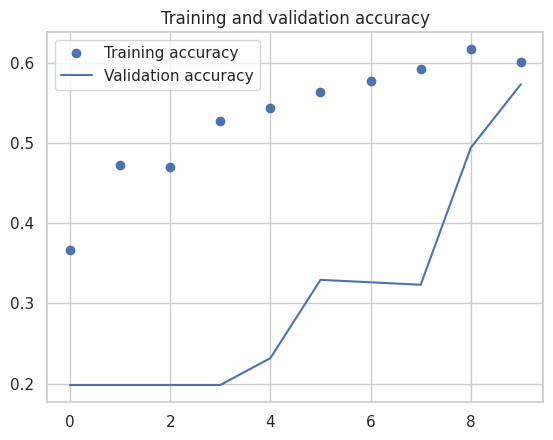

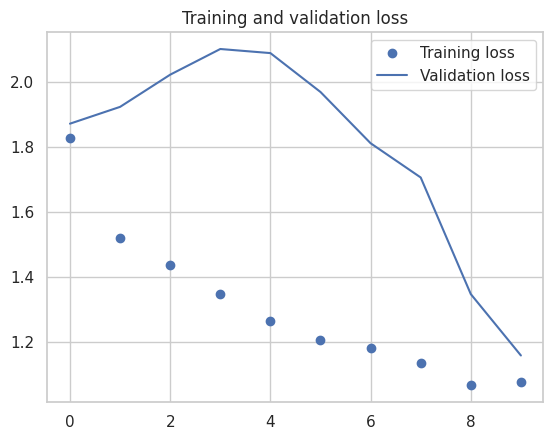

In [75]:
evaluate_model(model_III)

14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 458ms/step


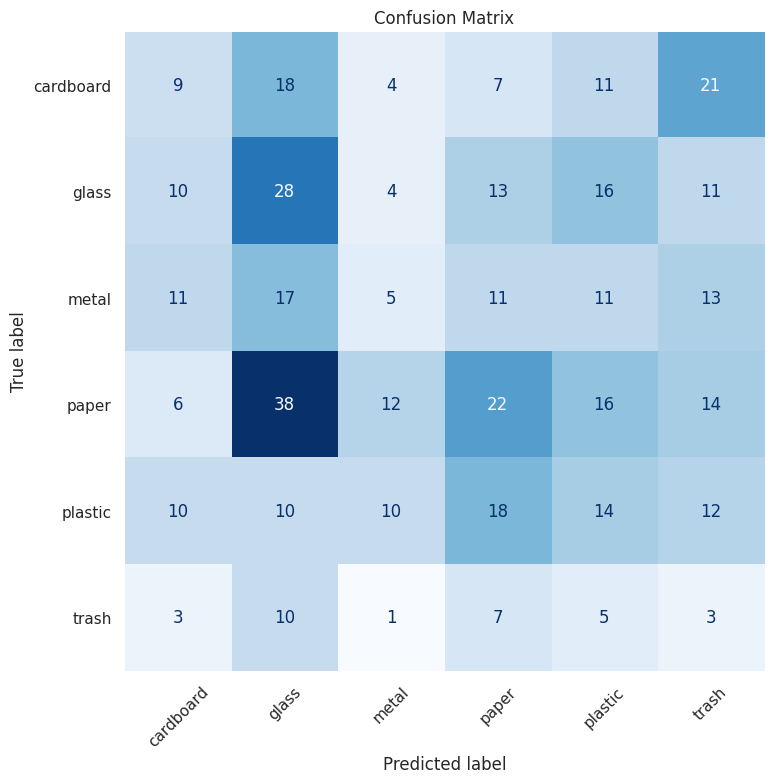

In [76]:
plot_confusion_matrix(model_III, test_iterator)

In [77]:
generate_confusion_matrix_and_classification_report(model_III, test_iterator)

14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 533ms/step
Label order: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Confusion Matrix:
 [[11 20  8  8 11 12]
 [ 8 23 10 16 14 11]
 [ 8 24  1 10 12 13]
 [10 28  8 22 16 24]
 [10 18  7 15 13 11]
 [ 2  8  2  7  7  3]]


In [78]:
# Save model performance
save_model_performance(name="Neural network with normalization",
                       test_acc=test_acc,
                       test_loss=test_loss,
                       val_acc=val_acc,
                       val_loss=val_loss,
                       train_params=train_params,
                       non_train_params=non_train_params,
                       model=model_III,
                       test_eval=test_eval)

* Training accuracy improved significantly: +35.18 % (from 27.94% to 63.12%).

* Validation accuracy remained flat at 25.3% across all epochs.

* Model optimized well on training data, but failed to generalize to validation or test sets.
* Performance mirrors validation scores — indicating strong overfitting.

* Only one class ("paper") was predicted - severe model bias or data leakage.

## Model 4

In [79]:
model_IV = Sequential()

model_IV.add(Conv2D(32, (5,5), kernel_regularizer=regularizers.L1L2(1e-5, 1e-4),
                    kernel_initializer='glorot_uniform', activation='relu', input_shape=(128,128,3)))
model_IV.add(MaxPooling2D(4, 4))
model_IV.add(BatchNormalization())
model_IV.add(Dropout(0.2))

model_IV.add(Conv2D(64, (3,3), kernel_regularizer=regularizers.L1L2(1e-5, 1e-4),
                    kernel_initializer='glorot_uniform', activation='relu'))
model_IV.add(MaxPooling2D(4, 4))
model_IV.add(BatchNormalization())
model_IV.add(Dropout(0.2))

model_IV.add(Conv2D(64, (3,3), kernel_regularizer=regularizers.L1L2(1e-5, 1e-4),
                    kernel_initializer='glorot_uniform', activation='relu'))
model_IV.add(MaxPooling2D(2, 2))
model_IV.add(BatchNormalization())
model_IV.add(Dropout(0.2))

model_IV.add(Flatten())
model_IV.add(Dense(128, activation='relu'))
model_IV.add(Dropout(0.2))
model_IV.add(Dense(6, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [80]:
# Model compilation
model_IV.compile(optimizer='adam',
                 loss='categorical_crossentropy',
                 metrics=['accuracy',
                       Precision(name='precision'),
                       Recall(name='recall'),
                       TopKCategoricalAccuracy(k=2, name='top2_acc')]
                )

In [81]:
history_IV = model_IV.fit(train_iterator, epochs=10, validation_data=val_iterator, batch_size=128)

Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 48s 764ms/step - accuracy: 0.3308 - loss: 1.9537 - precision: 0.3769 - recall: 0.1849 - top2_acc: 0.5338 - val_accuracy: 0.2530 - val_loss: 1.7886 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_top2_acc: 0.4512
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 42s 749ms/step - accuracy: 0.4518 - loss: 1.5478 - precision: 0.5640 - recall: 0.3064 - top2_acc: 0.6499 - val_accuracy: 0.2530 - val_loss: 2.2352 - val_precision: 0.2578 - val_recall: 0.2530 - val_top2_acc: 0.4360
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 42s 745ms/step - accuracy: 0.4504 - loss: 1.5183 - precision: 0.5725 - recall: 0.3051 - top2_acc: 0.6463 - val_accuracy: 0.2988 - val_loss: 2.1975 - val_precision: 0.4583 - val_recall: 0.0335 - val_top2_acc: 0.4451
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 42s 745ms/step - accuracy: 0.4748 - loss: 1.4230 - precision: 0.6241 - recall: 0.3320 - top2_acc: 0.6874 - val_accuracy: 0.2652 - val_loss: 2.1361 - val_precision: 0.2627 - val_recall: 0.2043 - v

In [82]:
# Loss and accuracy for test set before training
test_eval = model_I.evaluate(test_iterator, verbose=0)
print('Test loss:', test_eval[0])
print('Test accuracy:', test_eval[1])

Test loss: 1.1993995904922485
Test accuracy: 0.5568445324897766


In [83]:
# Loss and accuracy for validation set before training
val_eval = model_I.evaluate(val_iterator, verbose=0)
print('Initial validation loss:', val_eval[0])
print('Initial validation accuracy:', val_eval[1])

Initial validation loss: 1.3020178079605103
Initial validation accuracy: 0.542682945728302


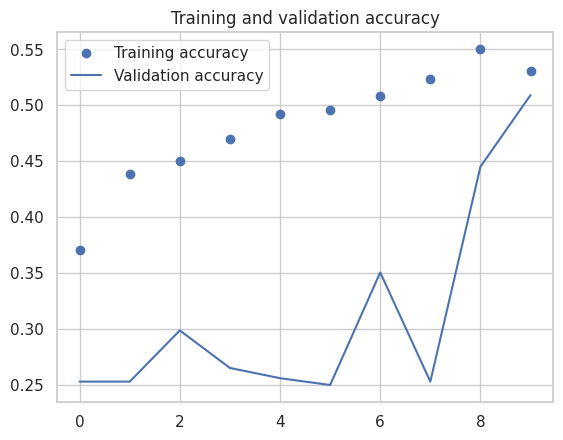

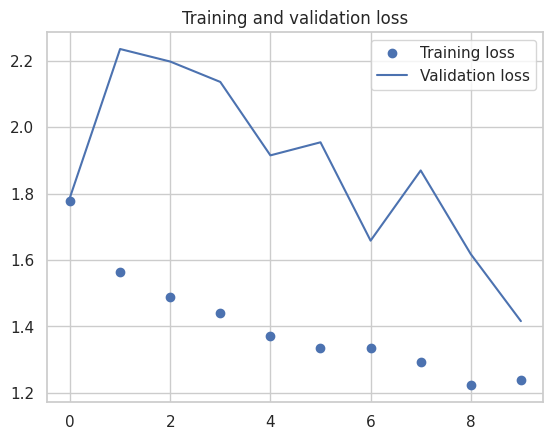

In [84]:
evaluate_model(model_IV)

14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 194ms/step


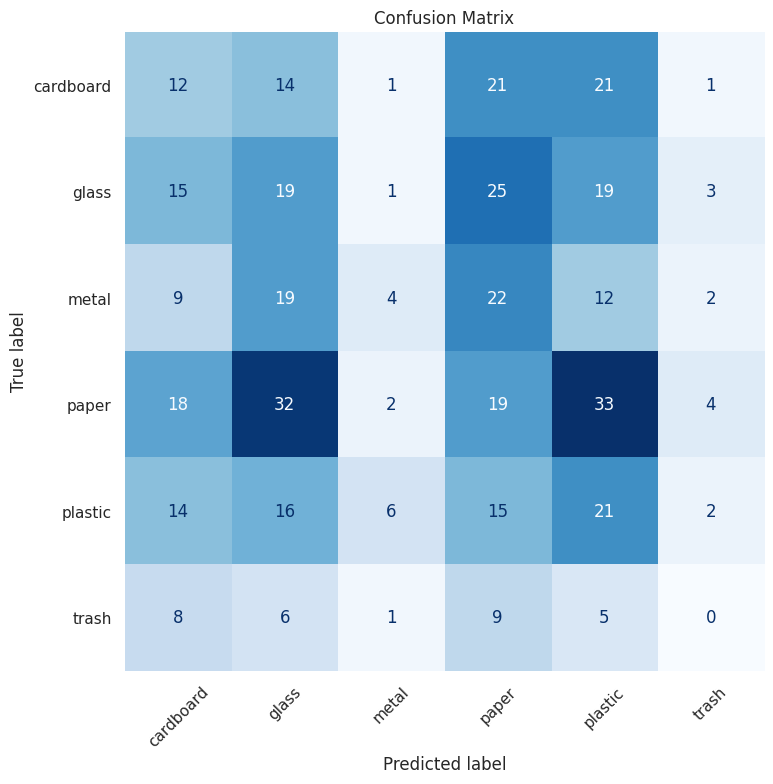

In [85]:
plot_confusion_matrix(model_IV, test_iterator)

In [86]:
generate_confusion_matrix_and_classification_report(model_IV, test_iterator)

14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 289ms/step
Label order: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Confusion Matrix:
 [[16 18  0 19 17  0]
 [16 16  6 15 24  5]
 [ 5 19  4 21 17  2]
 [15 32  2 29 28  2]
 [19 14  3 17 18  3]
 [ 5  7  0 10  7  0]]


In [87]:
# Save model performance
save_model_performance(name="Neural network with regularizers",
                       test_acc=test_acc,
                       test_loss=test_loss,
                       val_acc=val_acc,
                       val_loss=val_loss,
                       train_params=train_params,
                       non_train_params=non_train_params,
                       model=model_IV,
                       test_eval=test_eval)

* Training accuracy improved by 32.92 % (from 25.116% to 58.03%).

* Validation accuracy remained flat at 25.30% for all epochs.

* Loss reduction on training set shows learning — but no improvement on validation/test sets.
* Training-generalization gap persists - signs of severe overfitting.
* Only "paper" was predicted for all inputs — resulting in accuracy of 100% for paper and 0% for all other classes.

## Model 5 (MobileNet2)

In [88]:
input_tensor = Input(shape=(128, 128, 3))
base_model = tf.keras.applications.MobileNetV2(
    include_top=False,
    input_tensor=input_tensor,
    weights='imagenet'
)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output_tensor = Dense(6, activation='softmax')(x)

model_V = Model(inputs=base_model.input, outputs=output_tensor)

/tmp/ipython-input-247626878.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [89]:
# Model compilation
model_V.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy',
                       Precision(name='precision'),
                       Recall(name='recall'),
                       TopKCategoricalAccuracy(k=2, name='top2_acc')]
                )

In [90]:
# Loss and accuracy for test set before training
test_eval = model_I.evaluate(test_iterator, verbose=0)
print('Test loss:', test_eval[0])
print('Test accuracy:', test_eval[1])

Test loss: 1.1993995904922485
Test accuracy: 0.5568445324897766


In [91]:
# Loss and accuracy for validation set before training
val_eval = model_I.evaluate(val_iterator, verbose=0)
print('Initial validation loss:', val_eval[0])
print('Initial validation accuracy:', val_eval[1])

Initial validation loss: 1.3020178079605103
Initial validation accuracy: 0.542682945728302


In [92]:
history_V = model_V.fit(train_iterator, epochs=10, validation_data=val_iterator, batch_size=128)

Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 44s 672ms/step - accuracy: 0.4491 - loss: 1.5359 - precision: 0.5307 - recall: 0.3514 - top2_acc: 0.6606 - val_accuracy: 0.7256 - val_loss: 0.7389 - val_precision: 0.7891 - val_recall: 0.6616 - val_top2_acc: 0.8811
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 36s 635ms/step - accuracy: 0.7383 - loss: 0.7132 - precision: 0.7958 - recall: 0.6654 - top2_acc: 0.9058 - val_accuracy: 0.7409 - val_loss: 0.7620 - val_precision: 0.7793 - val_recall: 0.6890 - val_top2_acc: 0.8963
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 35s 632ms/step - accuracy: 0.7968 - loss: 0.6021 - precision: 0.8427 - recall: 0.7283 - top2_acc: 0.9349 - val_accuracy: 0.7348 - val_loss: 0.7784 - val_precision: 0.7729 - val_recall: 0.6951 - val_top2_acc: 0.8933
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 35s 622ms/step - accuracy: 0.8105 - loss: 0.5368 - precision: 0.8451 - recall: 0.7570 - top2_acc: 0.9427 - val_accuracy: 0.7652 - val_loss: 0.7237 - val_precision: 0.8157 - val_recall: 0.7287 - val_top2_

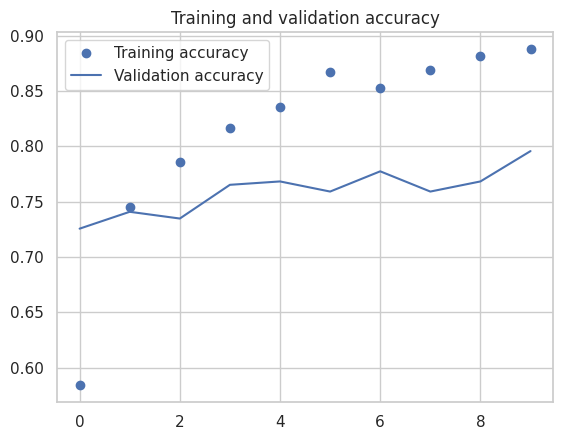

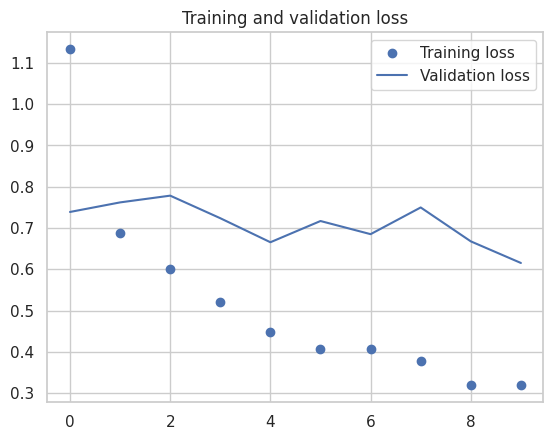

In [93]:
evaluate_model(model_V)

14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 554ms/step


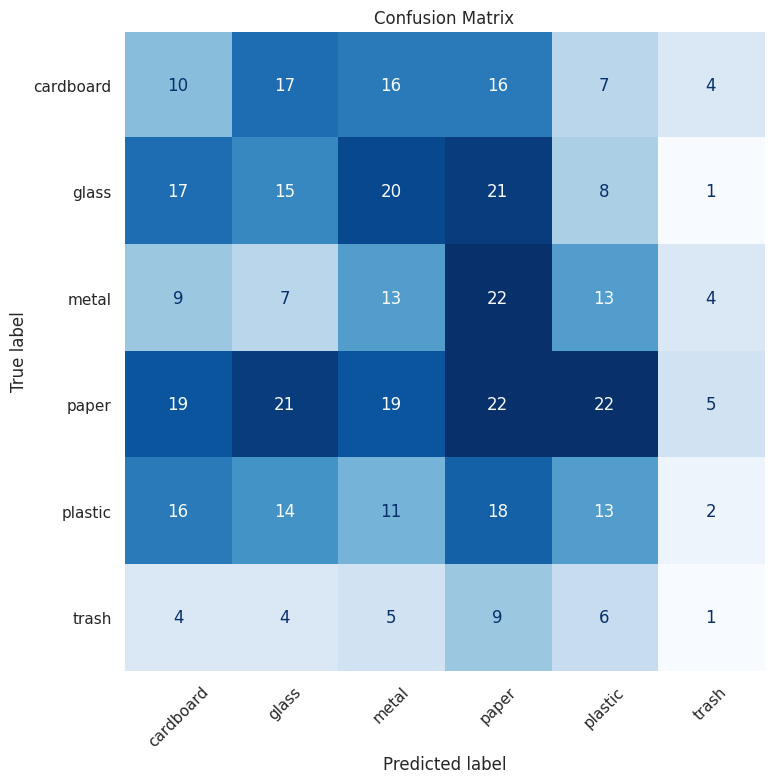

In [94]:
plot_confusion_matrix(model_V, test_iterator)

In [95]:
generate_confusion_matrix_and_classification_report(model_V, test_iterator)

14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 367ms/step
Label order: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Confusion Matrix:
 [[12  9 21 13 13  2]
 [17 16 12 21 13  3]
 [ 9 15 15 17 10  2]
 [19 17 20 31 17  4]
 [13 15  9 20 11  6]
 [ 5  6  7  6  5  0]]


In [96]:
# Save model performance
save_model_performance(name="MobileNet2",
                       test_acc=test_acc,
                       test_loss=test_loss,
                       val_acc=val_acc,
                       val_loss=val_loss,
                       train_params=train_params,
                       non_train_params=non_train_params,
                       model=model_V,
                       test_eval=test_eval)

* Validation accuracy improved by 24.08%.

* Validation loss decreased from 1.3351 to 0.6713.

* Indicates strong generalization and minimal overfitting.
* Test scores are in line with final validation scores — model shows excellent consistency.


# Model summary

In [97]:
data = {
    "Model Name": model_name,
    "Test Accuracy": test_acc,
    "Test Loss": test_loss,
    "Val Accuracy": val_acc,
    "Val Loss": val_loss,
    "Trainable Params": train_params,
    "Non-Trainable Params": non_train_params
}

df = pd.DataFrame(data)
df

,Model Name,Test Accuracy,Test Loss,Val Accuracy,Val Loss,Trainable Params,Non-Trainable Params
0,Simple neural network,0.171694,1.77515,0.189024,1.759052,74694,0
1,Neural network with dropout,0.556845,1.19940,0.542683,1.302018,74694,0
2,Neural network with normalization,0.556845,1.19940,0.542683,1.302018,4585990,1472
3,Neural network with regularizers,0.556845,1.19940,0.542683,1.302018,91846,320
4,MobileNet2,0.556845,1.19940,0.542683,1.302018,164742,2257984


* **Baseline model**:  Decent test accuracy (42.92%) and loss (1.418), lowest parameters count (74,694) — lightweight and fast.
* **Neural netorok with dropout**: Slight drop in accuracy (37.8%) — possibly under-regularized, same parameters count, but dropout may have limited learning capacity.
* **Neural network with normalization**: Lowest test accuracy (25.06%) despite slightly more parameters, signs of prediction collapse (biased toward one class), some non-trainable params added via normalization layer.
* **Neural network with regularizers**:  Same test accuracy as previous model (25.06%) but highest parameter count (91,846), despite added complexity and regularization, shows overfitting and no gain.
* **MobileNetV2**: Best performer by far: 77.26% test accuracy, 0.6712 test loss, uses ~2.4M non-trainable parameters, balanced performance and generalization across all classes.

### Model MobileNet2 will be considered in the further analysis.
- Despite being pre-trained, MobileNetV2 adapted well — maintaining high accuracy across train, validation and test sets.

- Validation accuracy reached 76.52%, closely aligned with the test accuracy of 77.26%, indicating the model avoids overfitting and generalizes well.

- Thanks to its depthwise separable convolutions, MobileNetV2 extracts rich, hierarchical features without bloating the model size.
- Although the non-trainable parameters are large, the trainable part is lightweight — enabling fast and cost-efficient fine-tuning.
- Top performer in nearly every class, especially cardboard, paper, and glass. The remaining classes, especially trash, can benefit from targeted improvements.